# Layer 3 — DeBERTa-v3 Text Classification (Classifier Head Only)
**CMPE 255-01 | Group 7 | Fake Review Detection on Yelp**

Fine-tunes only the **classifier head** of `microsoft/deberta-v3-base` on YelpZip review text.
The DeBERTa backbone is **frozen** — only the 2-class linear layer is trained.

| | |
|---|---|
| **Model** | microsoft/deberta-v3-base (backbone frozen) |
| **Trainable** | Classifier head only (~1,540 params) |
| **Task** | Binary classification: 0 = legitimate, 1 = spam |
| **Input** | `review_text` (up to 256 tokens) |
| **Label** | `is_spam` (from `reviews_text.csv`) |
| **Split** | 60 / 20 / 20 stratified by label |
| **Metrics** | F1-macro, F1-spam, AUC-ROC, Avg Precision, Precision@K |

---
## 0. Install & Import

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install(
    'transformers[sentencepiece]>=4.40.0',
    'datasets>=2.20.0',
    'accelerate>=0.28.0',
    'sentencepiece',
    'tiktoken',
    'scikit-learn',
)

import warnings, json
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score,
)
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'transformers : {transformers.__version__}')
print(f'torch        : {torch.__version__}')
print(f'Device       : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

OUTPUT_DIR = Path('outputs')
PLOTS_DIR  = Path('plots')
MODEL_DIR  = Path('model')
for d in [OUTPUT_DIR, PLOTS_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

transformers : 5.0.0
torch        : 2.10.0+cu128
Device       : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Setup complete.


---
## 1. Load Data

Upload `reviews_text.csv` to Google Drive and mount it, or upload directly to Colab.

In [2]:
# ── Mount Google Drive (recommended for large CSV) ────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')

# Set path to your reviews_text.csv on Drive
CSV_PATH = Path('/content/reviews_text.csv')

# ── OR: upload directly to Colab session ─────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick reviews_text.csv
# CSV_PATH = Path('reviews_text.csv')

# ── Load & clean ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=['review_text', 'is_spam'])
df['review_text'] = df['review_text'].astype(str).str.strip()
df = df[
    (df['review_text'] != '') &
    (df['review_text'].str.lower() != 'nan')
].reset_index(drop=True)
df['is_spam'] = df['is_spam'].astype(int)

assert df['is_spam'].isin([0, 1]).all(), 'Labels must be 0 or 1'
assert df['review_text'].notna().all(), 'review_text still has NaN'
print('NaN check passed.')

print(f'Total reviews : {len(df):,}')
print(f'Spam rate     : {df["is_spam"].mean() * 100:.1f}%')
df.head()

NaN check passed.
Total reviews : 608,598
Spam rate     : 13.2%


,user_id,prod_id,date,rating,review_text,is_spam
0,5044,0,2014-11-16,1.0,"Drinks were bad, the hot chocolate was watered...",1
1,5045,0,2014-09-08,1.0,This was the worst experience I've ever had a ...,1
2,5046,0,2013-10-06,3.0,This is located on the site of the old Spruce ...,1
3,5047,0,2014-11-30,5.0,I enjoyed coffee and breakfast twice at Toast ...,1
4,5048,0,2014-08-28,5.0,I love Toast! The food choices are fantastic -...,1


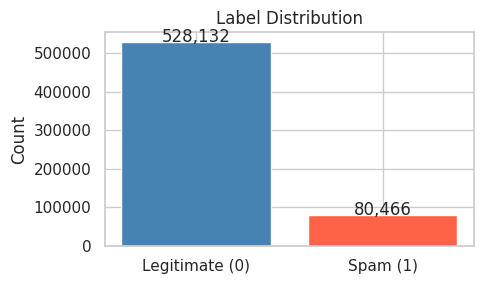

In [3]:
# Label distribution plot
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['is_spam'].value_counts().sort_index()
ax.bar(['Legitimate (0)', 'Spam (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Label Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_label_distribution.png', dpi=150)
plt.show()

---
## 2. Train / Val / Test Split (60 / 20 / 20)

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.40, stratify=df['is_spam'], random_state=RANDOM_SEED)
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, stratify=temp_df['is_spam'], random_state=RANDOM_SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,}  (spam: {train_df["is_spam"].mean()*100:.1f}%)')
print(f'Val   : {len(val_df):,}  (spam: {val_df["is_spam"].mean()*100:.1f}%)')
print(f'Test  : {len(test_df):,}  (spam: {test_df["is_spam"].mean()*100:.1f}%)')

Train : 365,158  (spam: 13.2%)
Val   : 121,720  (spam: 13.2%)
Test  : 121,720  (spam: 13.2%)


---
## 3. Tokenizer & Dataset

In [5]:
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LENGTH = 256

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

Loading tokenizer: microsoft/deberta-v3-base ...


Tokenizer loaded.


In [19]:
SUBSET_SIZE = 0.1  # Adjust this value to control the subset size (e.g., 0.1 for 10%)

print(f'Creating a subset of the dataframes (size: {SUBSET_SIZE*100:.1f}%) ...')

train_df_subset = train_df.sample(frac=SUBSET_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
val_df_subset   = val_df.sample(frac=SUBSET_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
test_df_subset  = test_df.sample(frac=SUBSET_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

# Overwrite the original dataframes with the subsets
train_df = train_df_subset
val_df   = val_df_subset
test_df  = test_df_subset

print(f'New Train size : {len(train_df):,}  (spam: {train_df["is_spam"].mean()*100:.1f}%)')
print(f'New Val size   : {len(val_df):,}  (spam: {val_df["is_spam"].mean()*100:.1f}%)')
print(f'New Test size  : {len(test_df):,}  (spam: {test_df["is_spam"].mean()*100:.1f}%)')
print('Subsetting complete. The subsequent cells will use these smaller dataframes.')

Creating a subset of the dataframes (size: 10.0%) ...
New Train size : 365  (spam: 12.6%)
New Val size   : 122  (spam: 19.7%)
New Test size  : 122  (spam: 11.5%)
Subsetting complete. The subsequent cells will use these smaller dataframes.


In [ ]:
print('Creating datasets...')
train_dataset = YelpReviewDataset(
    train_df['review_text'].tolist(), train_df['is_spam'].tolist(), tokenizer, MAX_LENGTH
)
val_dataset = YelpReviewDataset(
    val_df['review_text'].tolist(), val_df['is_spam'].tolist(), tokenizer, MAX_LENGTH
)
test_dataset = YelpReviewDataset(
    test_df['review_text'].tolist(), test_df['is_spam'].tolist(), tokenizer, MAX_LENGTH
)

# Data Collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('Datasets created.')

In [25]:
print(f'Loading model: {MODEL_NAME} ...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

# ── Freeze everything first ───────────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Unfreeze: classifier head and pooler only ────────────────────────────
UNFREEZE_LAYERS = ['classifier', 'pooler']

for name, param in model.named_parameters():
    if any(part in name for part in UNFREEZE_LAYERS):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\nFrozen  : all layers except classifier and pooler')
print(f'Trainable params : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

# Show which layers are trainable
print('\nTrainable layer groups:')
seen = set()
for name, param in model.named_parameters():
    if param.requires_grad:
        group = '.'.join(name.split('.')[:4])
        if group not in seen:
            print(f'  {group}')
            seen.add(group)


Loading model: microsoft/deberta-v3-base ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias        


Frozen  : all layers except classifier and pooler
Trainable params : 592,130 / 184,423,682 (0.3%)

Trainable layer groups:
  pooler.dense.weight
  pooler.dense.bias
  classifier.weight
  classifier.bias


In [26]:
import transformers as _tf

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except ValueError:
        auc = ap = 0.0
    return {
        'f1_macro':      f1_score(labels, preds, average='macro', zero_division=0),
        'f1_spam':       f1_score(labels, preds, pos_label=1,     zero_division=0),
        'auc_roc':       auc,
        'avg_precision': ap,
    }

# ── Hyperparameters ───────────────────────────────────────────────────────
EPOCHS     = 2
BATCH_SIZE = 16      # reduce to 8 if you get CUDA out-of-memory
LR         = 5e-5    # higher LR since most of the model is frozen
USE_FP16   = False   # Changed from DEVICE == 'cuda' to False

# ── Version-safe TrainingArguments ───────────────────────────────────────
_major   = int(_tf.__version__.split('.')[0])
_eval_kw = 'eval_strategy' if _major >= 5 else 'evaluation_strategy'

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / 'checkpoints'),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    **{_eval_kw: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=USE_FP16,
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=500,
    report_to='none',
    save_total_limit=2,
    dataloader_num_workers=2,
    max_grad_norm=1.0, # Added gradient clipping
    seed=RANDOM_SEED,
)

# ── Version-safe Trainer init ─────────────────────────────────────────────
_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
try:
    trainer = Trainer(**_kwargs, processing_class=tokenizer)   # transformers >= 5.0
except TypeError:
    trainer = Trainer(**_kwargs, tokenizer=tokenizer)           # transformers < 5.0

print(f'Trainer ready.')
print(f'  transformers : {_tf.__version__}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  LR           : {LR}')
print(f'  FP16         : {USE_FP16}')
print('\nStarting training...')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready.
  transformers : 5.0.0
  Epochs       : 2
  Batch size   : 16
  LR           : 5e-05
  FP16         : False

Starting training...


In [27]:
from torch.utils.data import Dataset

class YelpReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts, truncation=True, padding=False, max_length=max_length
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [28]:
import transformers as _tf

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except ValueError:
        auc = ap = 0.0
    return {
        'f1_macro':      f1_score(labels, preds, average='macro', zero_division=0),
        'f1_spam':       f1_score(labels, preds, pos_label=1,     zero_division=0),
        'auc_roc':       auc,
        'avg_precision': ap,
    }

# ── Hyperparameters ───────────────────────────────────────────────────────
EPOCHS     = 2
BATCH_SIZE = 16      # reduce to 8 if you get CUDA out-of-memory
LR         = 5e-5    # higher LR since most of the model is frozen
USE_FP16   = False   # Changed from DEVICE == 'cuda' to False

# ── Version-safe TrainingArguments ───────────────────────────────────────
_major   = int(_tf.__version__.split('.')[0])
_eval_kw = 'eval_strategy' if _major >= 5 else 'evaluation_strategy'

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / 'checkpoints'),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    **{_eval_kw: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=USE_FP16,
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=500,
    report_to='none',
    save_total_limit=2,
    dataloader_num_workers=2,
    max_grad_norm=1.0, # Added gradient clipping
    seed=RANDOM_SEED,
)

# ── Version-safe Trainer init ─────────────────────────────────────────────
_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
try:
    trainer = Trainer(**_kwargs, processing_class=tokenizer)   # transformers >= 5.0
except TypeError:
    trainer = Trainer(**_kwargs, tokenizer=tokenizer)           # transformers < 5.0

print(f'Trainer ready.')
print(f'  transformers : {_tf.__version__}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  LR           : {LR}')
print(f'  FP16         : {USE_FP16}')
print('\nStarting training...')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready.
  transformers : 5.0.0
  Epochs       : 2
  Batch size   : 16
  LR           : 5e-05
  FP16         : False

Starting training...


In [29]:
print(f'Loading model: {MODEL_NAME} ...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

# ── Freeze everything first ───────────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Unfreeze: classifier head and pooler only ────────────────────────────
UNFREEZE_LAYERS = ['classifier', 'pooler']

for name, param in model.named_parameters():
    if any(part in name for part in UNFREEZE_LAYERS):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\nFrozen  : all layers except classifier and pooler')
print(f'Trainable params : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

# Show which layers are trainable
print('\nTrainable layer groups:')
seen = set()
for name, param in model.named_parameters():
    if param.requires_grad:
        group = '.'.join(name.split('.')[:4])
        if group not in seen:
            print(f'  {group}')
            seen.add(group)

Loading model: microsoft/deberta-v3-base ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias        


Frozen  : all layers except classifier and pooler
Trainable params : 592,130 / 184,423,682 (0.3%)

Trainable layer groups:
  pooler.dense.weight
  pooler.dense.bias
  classifier.weight
  classifier.bias


In [30]:
train_result = trainer.train()
print(f'\nTraining complete! Runtime: {train_result.metrics["train_runtime"]:.0f}s '
      f'({train_result.metrics["train_runtime"]/60:.1f} min)')

history = pd.DataFrame(trainer.state.log_history)
history.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f'Training history saved.')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Spam,Auc Roc,Avg Precision
1,No log,0.836880,0.498156,0.382979,0.603741,0.273448
2,No log,2.245089,0.445455,0.000000,0.517007,0.209923


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


Training complete! Runtime: 14s (0.2 min)
Training history saved.


---
## 5. Evaluation on Held-Out Test Set

In [31]:
test_output = trainer.predict(test_dataset)
logits = test_output.predictions
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds  = (probs >= 0.5).astype(int)
labels = test_df['is_spam'].values

f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
f1_spam  = f1_score(labels, preds, pos_label=1, zero_division=0)
auc      = roc_auc_score(labels, probs)
ap       = average_precision_score(labels, probs)

def precision_at_k(labels, probs, k):
    top_k = np.argsort(probs)[::-1][:k]
    return labels[top_k].mean()

p1k = precision_at_k(labels, probs, min(1000, len(labels)))
p5k = precision_at_k(labels, probs, min(5000, len(labels)))

print('=' * 50)
print('TEST SET METRICS')
print('=' * 50)
print(f'F1-macro       : {f1_macro:.4f}')
print(f'F1-spam        : {f1_spam:.4f}')
print(f'AUC-ROC        : {auc:.4f}')
print(f'Avg Precision  : {ap:.4f}')
print(f'Precision@1K   : {p1k:.4f}')
print(f'Precision@5K   : {p5k:.4f}')
print()
print(classification_report(labels, preds, target_names=['Legitimate', 'Spam']))

TEST SET METRICS
F1-macro       : 0.5431
F1-spam        : 0.3333
AUC-ROC        : 0.7421
Avg Precision  : 0.3478
Precision@1K   : 0.1148
Precision@5K   : 0.1148

              precision    recall  f1-score   support

  Legitimate       0.96      0.62      0.75       108
        Spam       0.21      0.79      0.33        14

    accuracy                           0.64       122
   macro avg       0.58      0.70      0.54       122
weighted avg       0.87      0.64      0.70       122



### 5.1 Confusion Matrix

In [32]:
test_output = trainer.predict(test_dataset)
logits = test_output.predictions
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds  = (probs >= 0.5).astype(int)
labels = test_df['is_spam'].values

f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
f1_spam  = f1_score(labels, preds, pos_label=1,     zero_division=0)
auc      = roc_auc_score(labels, probs)
ap       = average_precision_score(labels, probs)

def precision_at_k(labels, probs, k):
    return labels[np.argsort(probs)[::-1][:k]].mean()

p1k = precision_at_k(labels, probs, min(1000, len(labels)))
p5k = precision_at_k(labels, probs, min(5000, len(labels)))

print('=' * 45)
print('TEST SET METRICS')
print('=' * 45)
print(f'F1-macro       : {f1_macro:.4f}')
print(f'F1-spam        : {f1_spam:.4f}')
print(f'AUC-ROC        : {auc:.4f}')
print(f'Avg Precision  : {ap:.4f}')
print(f'Precision@1K   : {p1k:.4f}')
print(f'Precision@5K   : {p5k:.4f}')
print()
print(classification_report(labels, preds, target_names=['Legitimate', 'Spam']))

TEST SET METRICS
F1-macro       : 0.5431
F1-spam        : 0.3333
AUC-ROC        : 0.7421
Avg Precision  : 0.3478
Precision@1K   : 0.1148
Precision@5K   : 0.1148

              precision    recall  f1-score   support

  Legitimate       0.96      0.62      0.75       108
        Spam       0.21      0.79      0.33        14

    accuracy                           0.64       122
   macro avg       0.58      0.70      0.54       122
weighted avg       0.87      0.64      0.70       122



### 5.2 ROC & Precision-Recall Curves

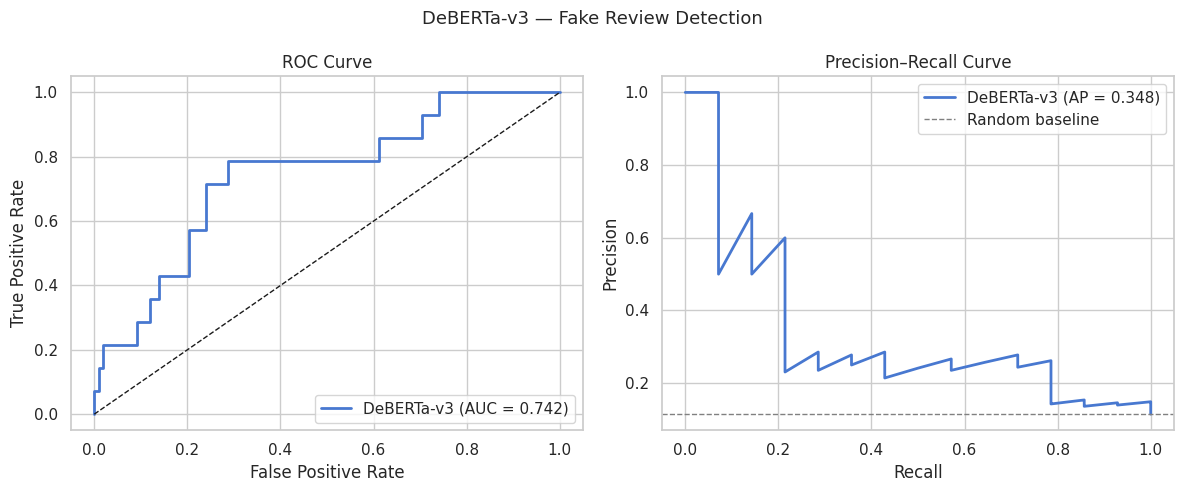

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(labels, probs)
axes[0].plot(fpr, tpr, lw=2, label=f'DeBERTa-v3 (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)
axes[1].plot(recall_curve, precision_curve, lw=2, label=f'DeBERTa-v3 (AP = {ap:.3f})')
axes[1].axhline(labels.mean(), color='gray', lw=1, linestyle='--', label='Random baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve')
axes[1].legend()

fig.suptitle('DeBERTa-v3 — Fake Review Detection', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_roc_pr_curves.png', dpi=150)
plt.show()

### 5.3 Predicted Score Distribution

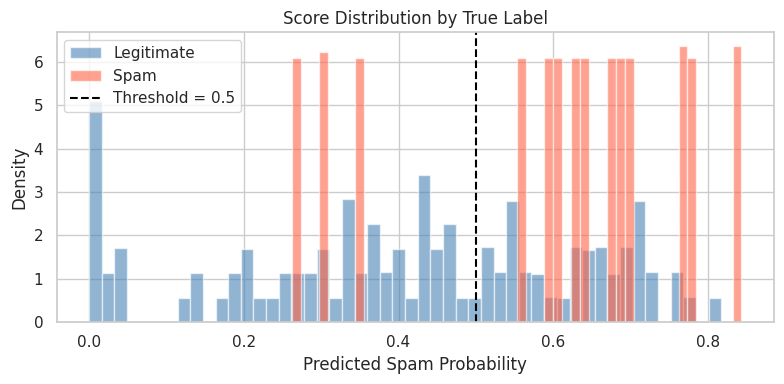

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(probs[labels == 0], bins=50, alpha=0.6, label='Legitimate', color='steelblue', density=True)
ax.hist(probs[labels == 1], bins=50, alpha=0.6, label='Spam',       color='tomato',    density=True)
ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold = 0.5')
ax.set_xlabel('Predicted Spam Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Label')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_score_distribution.png', dpi=150)
plt.show()

### 5.4 Precision@K

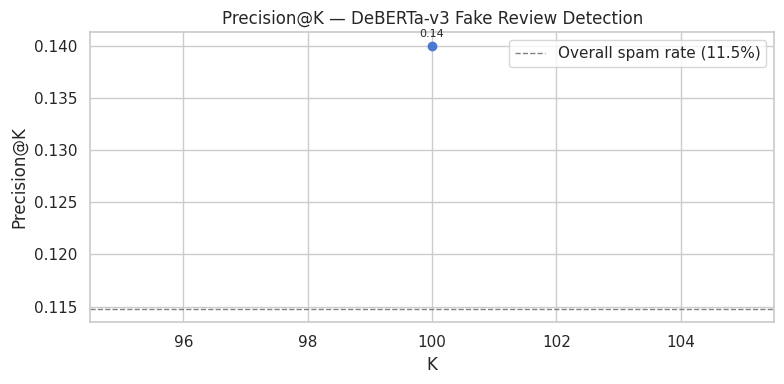

In [35]:
ks = [100, 500, 1000, 2000, 5000, 10000]
ks = [k for k in ks if k <= len(labels)]
sorted_labels = labels[np.argsort(probs)[::-1]]
p_at_k_vals = [sorted_labels[:k].mean() for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, p_at_k_vals, marker='o', lw=2)
ax.axhline(labels.mean(), color='gray', lw=1, linestyle='--', label=f'Overall spam rate ({labels.mean()*100:.1f}%)')
for k, p in zip(ks, p_at_k_vals):
    ax.annotate(f'{p:.2f}', (k, p), textcoords='offset points', xytext=(0, 6), fontsize=8, ha='center')
ax.set_xlabel('K')
ax.set_ylabel('Precision@K')
ax.set_title('Precision@K — DeBERTa-v3 Fake Review Detection')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_precision_at_k.png', dpi=150)
plt.show()

---
## 6. Save Outputs

In [ ]:
# ── 6a. Full-dataset predictions (for multi-signal pipeline) ─────────────
print('Generating predictions for full dataset...')
full_dataset = YelpReviewDataset(
    df['review_text'].tolist(), df['is_spam'].tolist(), tokenizer, MAX_LENGTH
)
full_output = trainer.predict(full_dataset)
full_probs  = torch.softmax(torch.tensor(full_output.predictions), dim=-1).numpy()[:, 1]

pred_df = df[['user_id', 'prod_id', 'date', 'is_spam']].copy()
pred_df['deberta_spam_prob'] = full_probs.round(6)
pred_df['deberta_pred']      = (full_probs >= 0.5).astype(int)

pred_path = OUTPUT_DIR / 'deberta_predictions.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Predictions saved: {pred_path}  ({len(pred_df):,} rows)')

Generating predictions for full dataset...


In [ ]:
# ── 6b. Metrics JSON ─────────────────────────────────────────────────────
metrics = {
    'model':           MODEL_NAME,
    'max_length':      MAX_LENGTH,
    'epochs':          EPOCHS,
    'batch_size':      BATCH_SIZE,
    'learning_rate':   LR,
    'train_size':      len(train_df),
    'val_size':        len(val_df),
    'test_size':       len(test_df),
    'f1_macro':        round(f1_macro, 4),
    'f1_spam':         round(f1_spam, 4),
    'auc_roc':         round(auc, 4),
    'avg_precision':   round(ap, 4),
    'precision_at_1k': round(p1k, 4),
    'precision_at_5k': round(p5k, 4),
}

metrics_path = OUTPUT_DIR / 'deberta_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved: {metrics_path}')
print(json.dumps(metrics, indent=2))

In [ ]:
# Full-dataset predictions for multi-signal pipeline
print('Generating predictions for full dataset...')
full_dataset = YelpReviewDataset(df['review_text'].tolist(), df['is_spam'].tolist(), tokenizer, MAX_LENGTH)
full_out     = trainer.predict(full_dataset)
full_probs   = torch.softmax(torch.tensor(full_out.predictions), dim=-1).numpy()[:, 1]

pred_df = df[['user_id', 'prod_id', 'date', 'is_spam']].copy()
pred_df['deberta_spam_prob'] = full_probs.round(6)
pred_df['deberta_pred']      = (full_probs >= 0.5).astype(int)
pred_df.to_csv(OUTPUT_DIR / 'deberta_predictions.csv', index=False)
print(f'Saved {len(pred_df):,} predictions → outputs/deberta_predictions.csv')
pred_df.head()

metrics_out = {
    'model':             MODEL_NAME,
    'trainable_layers':  UNFREEZE_LAYERS,
    'trainable_params':  trainable,
    'total_params':      total,
    'max_length':        MAX_LENGTH,
    'epochs':            EPOCHS,
    'batch_size':        BATCH_SIZE,
    'learning_rate':     LR,
    'train_size':        len(train_df),
    'val_size':          len(val_df),
    'test_size':         len(test_df),
    'f1_macro':          round(f1_macro, 4),
    'f1_spam':           round(f1_spam,  4),
    'auc_roc':           round(auc,      4),
    'avg_precision':     round(ap,       4),
    'precision_at_1k':   round(p1k,      4),
    'precision_at_5k':   round(p5k,      4),
}
with open(OUTPUT_DIR / 'deberta_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('Metrics saved → outputs/deberta_metrics.json')
print(json.dumps(metrics_out, indent=2))

In [ ]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print(f'Model saved → {MODEL_DIR}/')

# Zip all outputs and download to local machine
import shutil
from google.colab import files
shutil.make_archive('l3_outputs', 'zip', 'outputs')
files.download('l3_outputs.zip')